In [6]:
import numpy as np
import matplotlib.pyplot as plt
from bipangolin import BiPangolinRunner

# Initialise the runner 
# If auto-download fails, use: runner = BiPangolinRunner(pangolin_model_dir="/path/to/your/models")
runner = BiPangolinRunner(tissue = 'all_tissues') 

# Define your sequence here
my_sequence = (
"ggtttagtgaaccgtcagatcagatctttgtcgatcctaccatccactcgacacacccgccagcggccgcttcttggtgccagcttatcatagcgctaccggtcgccaccatggcgagaacaatggtcgcgatggtatctaagggcgaagcaggtaagcggcgtgcttgttgcgtggttggggtgtgggtgtgagtgggatgggagagtggttgtcgcgtgtggttggctcgggtgcttggatgggtgattgtcggcgtgtttgacagtgataaaagagtttatgagattcaaagtccacatggagggatcaatgaacggacacgaatttgaaattgaaggcgagggcgaaggaagaccttatgaggggacacagaccgccaaggtgcgtgcgtggatcgtgtgcatgtggggtggttgattaggggtgtatggctgggtgattgaggcgtgtatggtggtgtggatgacaagagtgattgttggtgtgaatgacgagtgactgtctaacgtcttgaccgattctacagttgaaggttacgaagggcgggcctctgcccttctcttgggatatcctgagcccgcagtttatgtacggcagccgggctttcaccaaacaccctgccgatatcccagactactataaacagtcctttccagaaggatttaagtgggagcgagtcatgaatttcgaggacggaggtgccgtgacggttactcaggacaccagcctggaggacggcaccctgatctacaaggtgaagctgaggggcaccaacttcccccccgacggccccgtgatgcagaagaagaccatgggctgggaggccagcaccgagaggctgtaccccgaggacggcgtgctgaagggcgacatcaagatggccctgaggctgaaggacggcggcaggtacctggccgacttcaagaccacctacaaggccaagaagcccgtgcagatgcccggcgcctacaacgtggacaggaagctggacatcaccagccacaacgaggactacaccgtggtggagcagtacgagaggagcgagggcaggcacagcaccggcggcatggacgagctgtacaaggactacaaggacgatgatgacaagtgataaacaaatggtaaggaagggcacatcaatctttgcttaattgtcctttactctaaagatgtattttatcatactgaatgctaaacttgatatctccttttaggtcattgatgtccttcaccccgggaaggcgacagtgcctaagacagaaattcgggaaaaactagccaaaatgtacaagaccacaccggatgtcatctttgtatttggattcagaactcagtaaactggatccgcaggcctctgctagcttgactgactgagatacagcgtaccttcagctcacagacatga"
).upper()

# Score the sequence
print(f"Scoring sequence of length {len(my_sequence)}...")
result = runner.score_sequence(my_sequence)
print("Scoring complete!")

biPangolin: 12 model+probe pairs ready on mps
biPangolin: correction k=502.2
Scoring sequence of length 1408...
Scoring complete!


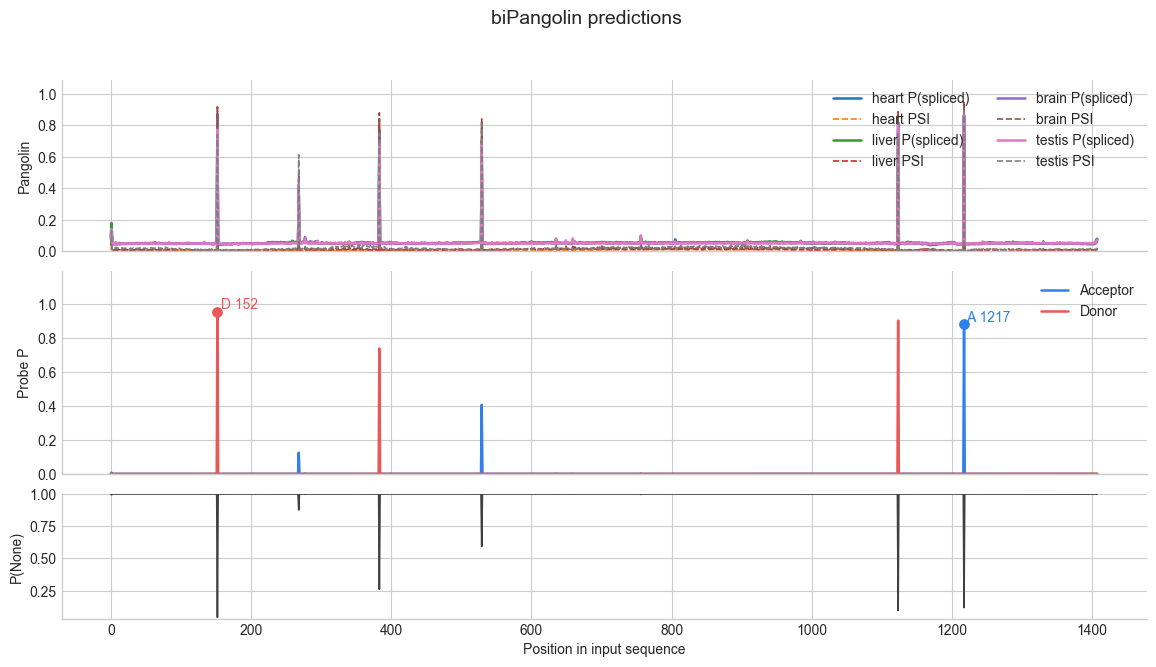

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bipangolin_result(result, start=0, end=None, title="biPangolin prediction"):
    if end is None:
        end = len(result)

    x = np.arange(start, end)

    donor = result.probe_donor[start:end].detach().cpu().numpy()
    acceptor = result.probe_acceptor[start:end].detach().cpu().numpy()
    none = result.probe_none[start:end].detach().cpu().numpy()

    pangolin_prob = result.pangolin_prob[:, start:end].detach().cpu().numpy()
    pangolin_psi = result.pangolin_psi[:, start:end].detach().cpu().numpy()

    fig, axes = plt.subplots(
        3, 1,
        figsize=(14, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [1.1, 1.3, 0.8], "hspace": 0.12}
    )

    ax = axes[0]
    for i, tissue in enumerate(result.tissues):
        ax.plot(x, pangolin_prob[i], lw=1.8, label=f"{tissue} P(spliced)")
        ax.plot(x, pangolin_psi[i], lw=1.2, ls="--", label=f"{tissue} PSI")
    ax.set_ylabel("Pangolin")
    ax.set_ylim(0, max(0.05, np.nanmax([pangolin_prob.max(), pangolin_psi.max()]) * 1.15))
    ax.legend(loc="upper right", frameon=False, ncols=2)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.fill_between(x, acceptor, color="#2f80ed", alpha=0.25)
    ax.plot(x, acceptor, color="#2f80ed", lw=1.8, label="Acceptor")
    ax.fill_between(x, donor, color="#eb5757", alpha=0.25)
    ax.plot(x, donor, color="#eb5757", lw=1.8, label="Donor")

    acc_peak = int(np.argmax(acceptor)) + start
    don_peak = int(np.argmax(donor)) + start
    ax.scatter([acc_peak], [result.probe_acceptor[acc_peak]], color="#2f80ed", s=45, zorder=5)
    ax.scatter([don_peak], [result.probe_donor[don_peak]], color="#eb5757", s=45, zorder=5)
    ax.text(acc_peak, float(result.probe_acceptor[acc_peak]), f" A {acc_peak}", color="#2f80ed", va="bottom")
    ax.text(don_peak, float(result.probe_donor[don_peak]), f" D {don_peak}", color="#eb5757", va="bottom")

    ax.set_ylabel("Probe P")
    ax.set_ylim(0, max(0.05, np.nanmax([acceptor.max(), donor.max()]) * 1.25))
    ax.legend(loc="upper right", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[2]
    ax.plot(x, none, color="0.25", lw=1.2)
    ax.set_ylabel("P(None)")
    ax.set_ylim(max(0, none.min() - 0.01), 1.001)
    ax.set_xlabel("Position in input sequence")
    ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(title, y=0.98, fontsize=14)
    return fig, axes

fig, axes = plot_bipangolin_result(result, title="biPangolin predictions")
plt.show()


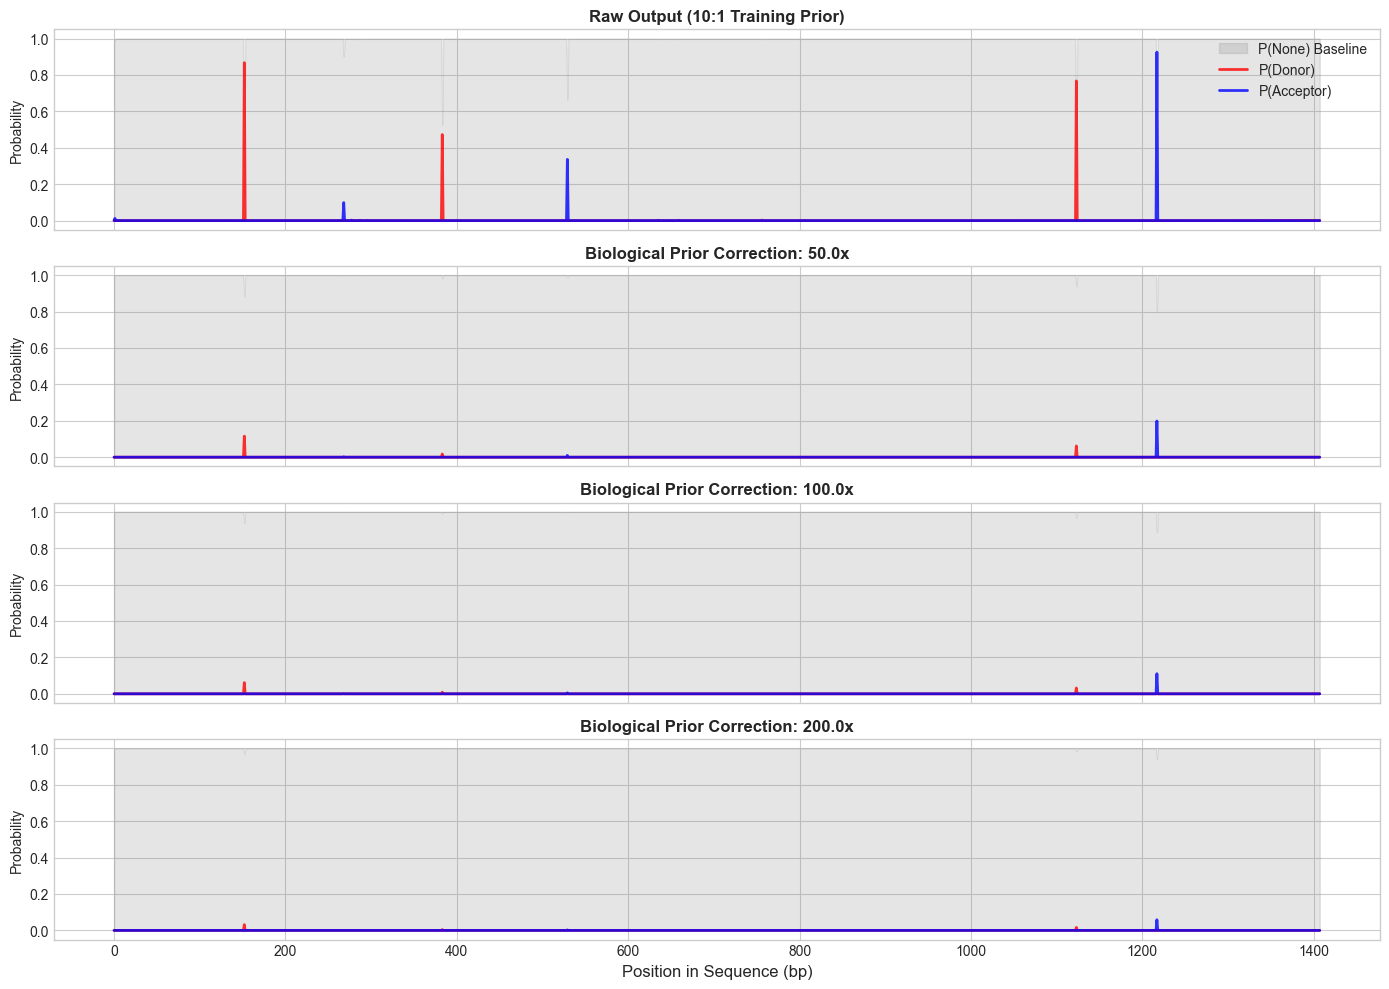

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def apply_prior_correction(result, none_multiplier=100.0):
    """
    Corrects the probabilities based on the ratio between the real-world 
    background frequency and the artificially balanced training frequency.
    """
    # 1. Multiply the 'None' class by the scaling factor
    # We leave Acceptor and Donor multiplied by 1.
    scaled_none = result.probe_none * none_multiplier
    scaled_acceptor = result.probe_acceptor * 1.0
    scaled_donor = result.probe_donor * 1.0
    
    # 2. Re-normalize so everything sums to 1.0 again
    total = scaled_none + scaled_acceptor + scaled_donor
    
    final_none = scaled_none / total
    final_acceptor = scaled_acceptor / total
    final_donor = scaled_donor / total
    
    return final_none.numpy(), final_acceptor.numpy(), final_donor.numpy()

# --- Plot the correction ---
plt.style.use('seaborn-v0_8-whitegrid')

# Let's test a few biological prior assumptions
correction_factors = [1.0, 50.0, 100.0, 200.0]

fig, axes = plt.subplots(nrows=len(correction_factors), ncols=1, 
                         figsize=(14, 2.5 * len(correction_factors)), sharex=True)

x_coords = np.arange(len(my_sequence))

for ax, multiplier in zip(axes, correction_factors):
    # Apply the mathematical correction
    corr_none, corr_acc, corr_don = apply_prior_correction(result, none_multiplier=multiplier)
    
    # 1. Plot P(None) background
    ax.fill_between(x_coords, corr_none, color='gray', alpha=0.2, label='P(None) Baseline')
    
    # 2. Plot Acceptor and Donor
    ax.plot(x_coords, corr_don, label='P(Donor)', color='red', alpha=0.8, linewidth=2)
    ax.plot(x_coords, corr_acc, label='P(Acceptor)', color='blue', alpha=0.8, linewidth=2)
    
    # Aesthetics
    title = f'Biological Prior Correction: {multiplier}x' if multiplier != 1.0 else 'Raw Output (10:1 Training Prior)'
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Probability')
    ax.set_ylim([-0.05, 1.05])
    
    if multiplier == 1.0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel('Position in Sequence (bp)', fontsize=12)

plt.tight_layout()
plt.show()